In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os



import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.utils.image_utils import img_to_array
from tensorflow.keras.utils import load_img
from keras.applications.vgg19 import VGG19,preprocess_input, decode_predictions

In [ ]:
train_datagen=ImageDataGenerator(zoom_range=0.5, shear_range=0.3,horizontal_flip=True,preprocessing_function=preprocess_input)
val_datagen=ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)


Mounted at /content/gdrive


In [ ]:
!unzip gdrive/My\ Drive/data/archive.zip

Streaming output truncated to the last 5000 lines.
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665_270deg.JPG  
  inflating: new plant diseases dataset(augmented)/New 

In [ ]:
from google.colab.patches import cv2_imshow
from skimage import io

Grape Black rot


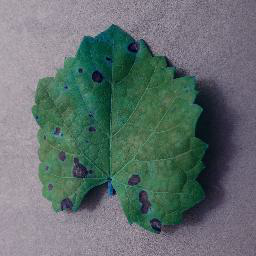

Apple Healthy


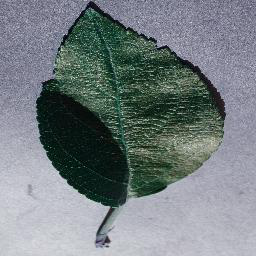

potato late blight


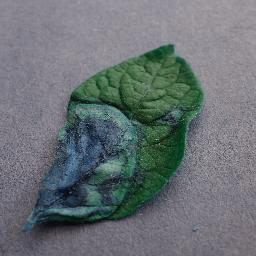

In [ ]:

image1 = io.imread("/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___Black_rot/00090b0f-c140-4e77-8d20-d39f67b75fcc___FAM_B.Rot 0376_flipLR.JPG")
image2=io.imread("/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___healthy/0055dd26-23a7-4415-ac61-e0b44ebfaf80___RS_HL 5672.JPG")
image3=io.imread("/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Potato___Late_blight/0051e5e8-d1c4-4a84-bf3a-a426cdad6285___RS_LB 4640.JPG")
print("Grape Black rot")
cv2_imshow(image1)
print("Apple Healthy")
cv2_imshow(image2)
print("potato late blight")
cv2_imshow(image3)

In [ ]:
train=train_datagen.flow_from_directory(directory="/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",target_size=(256,256),batch_size=32)
val=val_datagen.flow_from_directory(directory="/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",target_size=(256,256),batch_size=32)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [ ]:
t_img ,label=train.next()

In [ ]:
def plotImage(img_arr, label):

  for im , l in zip(img_arr ,label):
    plt.figure(figsize=(5,5))
    plt.imshow(im)
    plt.show()

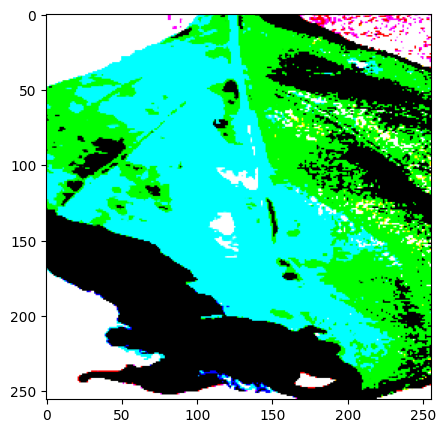

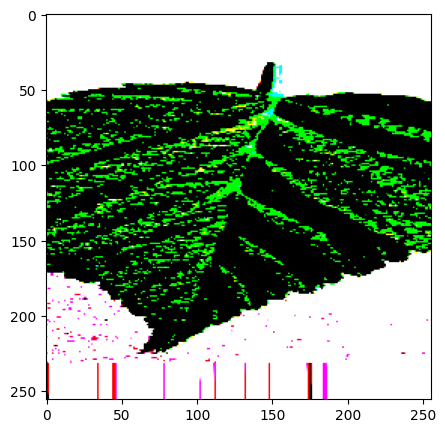

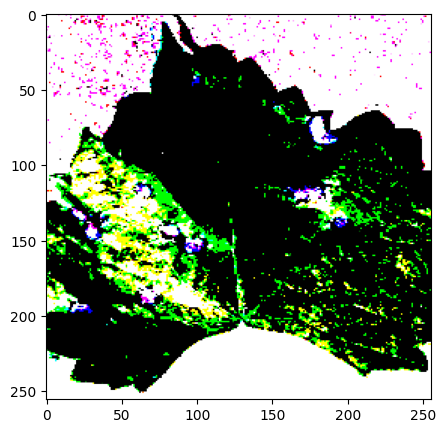

In [ ]:
plotImage(t_img[:3],label[:3])

Building model

In [ ]:
from keras.layers import Dense,Flatten
from keras.models import Model
from keras.applications.vgg19 import VGG19
import keras

In [ ]:
base_model=VGG19(input_shape=(256,256,3), include_top=False)

80134624/80134624 [==============================] - 0s 0us/step


In [ ]:
for layer in base_model.layers:
  layer.trainable=False

In [ ]:
base_model.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 256, 256, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 256, 256, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 128, 128, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 128, 128, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 128, 128, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 64, 64, 128)       0     

In [ ]:
X =Flatten()(base_model.output)
X =Dense(units=38,activation='softmax')(X)
#creating model
model=Model(base_model.input, X)

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 256, 256, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 256, 256, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 128, 128, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 128, 128, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 128, 128, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 64, 64, 128)       0     

In [ ]:
model.compile(optimizer='adam' ,loss=keras.losses.categorical_crossentropy , metrics=['accuracy'])

Early Stopping and Model Check point

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping


#early stopping
es=EarlyStopping(monitor='val_accuracy' ,min_delta=0.01,patience=3,verbose=1)

#model check point
mc=ModelCheckpoint(filepath="best_model.h5",monitor='val_accuracy',min_delta=0.01,patience=3,verbose=1,save_best_only=True)

cb=[es,mc]


In [ ]:
his = model.fit_generator(train ,
                          steps_per_epoch=16,
                          epochs= 50,
                          verbose= 1,
                          callbacks= cb,
                          validation_data=val ,
                          validation_steps= 16)

<ipython-input-19-35c508c20069>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  his = model.fit_generator(train ,


Epoch 1/50
16/16 [==============================] - ETA: 0s - loss: 27.3950 - accuracy: 0.1797
Epoch 1: val_accuracy improved from -inf to 0.40234, saving model to best_model.h5
16/16 [==============================] - 29s 973ms/step - loss: 27.3950 - accuracy: 0.1797 - val_loss: 12.2044 - val_accuracy: 0.4023
Epoch 2/50
16/16 [==============================] - ETA: 0s - loss: 17.3798 - accuracy: 0.3828
Epoch 2: val_accuracy improved from 0.40234 to 0.55273, saving model to best_model.h5
16/16 [==============================] - 13s 844ms/step - loss: 17.3798 - accuracy: 0.3828 - val_loss: 9.9461 - val_accuracy: 0.5527
Epoch 3/50
16/16 [==============================] - ETA: 0s - loss: 10.2250 - accuracy: 0.5352
Epoch 3: val_accuracy improved from 0.55273 to 0.60938, saving model to best_model.h5
16/16 [==============================] - 14s 903ms/step - loss: 10.2250 - accuracy: 0.5352 - val_loss: 10.0614 - val_accuracy: 0.6094
Epoch 4/50
16/16 [==============================] - ETA: 0s

In [ ]:
h=his.history
h.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

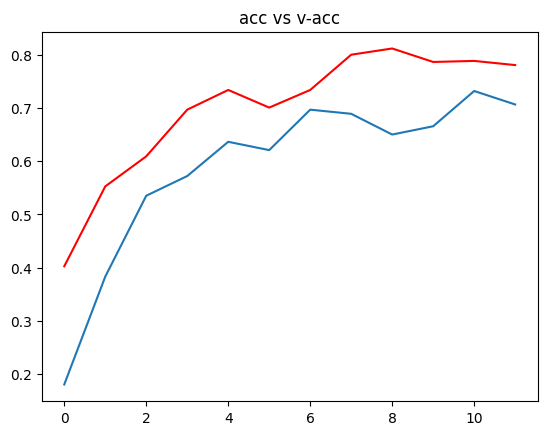

In [ ]:
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'],c="red")
plt.title("acc vs v-acc")
plt.show()

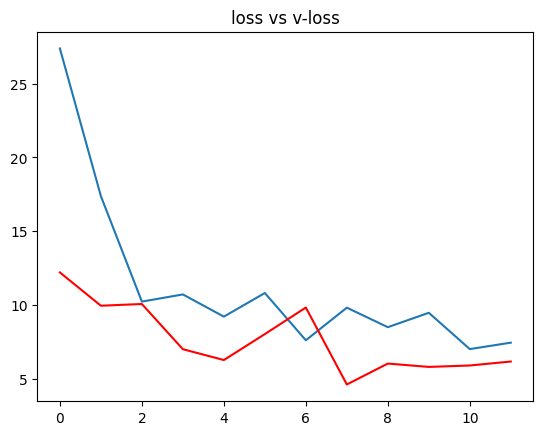

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'],c="red")
plt.title("loss vs v-loss")
plt.show()

In [ ]:
# load best model
from keras.models import load_model
model=load_model('/content/best_model.h5')

In [ ]:
acc=model.evaluate_generator(val)[1]



<ipython-input-24-24d2a675543c>:1: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  acc=model.evaluate_generator(val)[1]


In [ ]:
ref=dict(zip(list(train.class_indices.values()) , list(train.class_indices.keys())))

In [ ]:
def prediction(path):
  img=load_img(path,target_size=(256,256))
  i=img_to_array(img)
  im=preprocess_input(i)
  img=np.expand_dims(im,axis=0)
  pred=np.argmax(model.predict(img))
  print(f" the image belongs to { ref[pred] } " )

In [ ]:
from google.colab.patches import cv2_imshow
from skimage import io

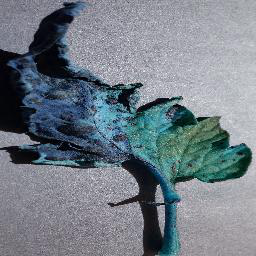

1/1 [==============================] - 0s 21ms/step
 the image belongs to Tomato___Early_blight 


In [ ]:
path="/content/test/test/TomatoEarlyBlight1.JPG"
image = io.imread(path)
cv2_imshow(image)
prediction(path)